# Credit Card Fraud Detection

Fraud is only about 0.17% of the transactions in this dataset, so a model can look great on accuracy and still be useless. This notebook tries a few ways of dealing with that and compares them fairly.

**Data:** [Credit Card Fraud Detection (Kaggle)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud), 284,807 transactions. `V1` to `V28` are anonymized (PCA), `Time` and `Amount` are raw, `Class` is 1 for fraud.

*Based on a GeeksforGeeks tutorial. I added the undersampling comparison, XGBoost, a stratified split, and threshold tuning.*

## 1. Setup

```bash
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost
```

Download `creditcard.csv` from Kaggle and put it next to this notebook. It's about 150 MB, so it's not in the repo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay, precision_recall_curve,
                             recall_score, precision_score, f1_score,
                             average_precision_score, roc_auc_score)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier

data = pd.read_csv("creditcard.csv")
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Quick look at the data

Normal: 284,315   Fraud: 492   Fraud share: 0.173%


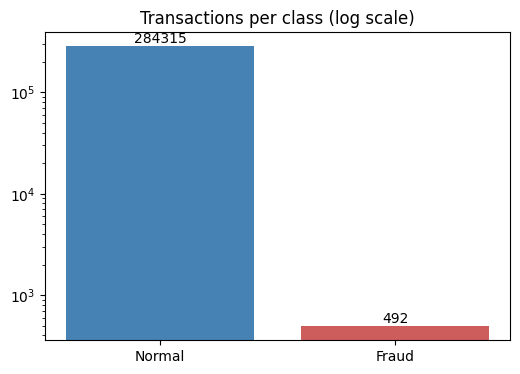

In [2]:
counts = data['Class'].value_counts()
print(f"Normal: {counts[0]:,}   Fraud: {counts[1]:,}   Fraud share: {counts[1] / len(data):.3%}")

plt.figure(figsize=(6, 4))
bars = plt.bar(['Normal', 'Fraud'], [counts[0], counts[1]], color=['steelblue', 'indianred'])
plt.bar_label(bars)
plt.yscale('log')
plt.title('Transactions per class (log scale)')
plt.show()

A model that always says "not fraud" would be about 99.8% accurate. So I'll look at recall, precision, F1 and PR-AUC instead.

In [3]:
data.groupby('Class')['Amount'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.29,250.11,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.21,256.68,0.0,1.00,9.25,105.89,2125.87


Fraud has a slightly higher mean amount but a lower median (about \$9 vs \$22). Most fraud is small, with a few large ones pulling the mean up.

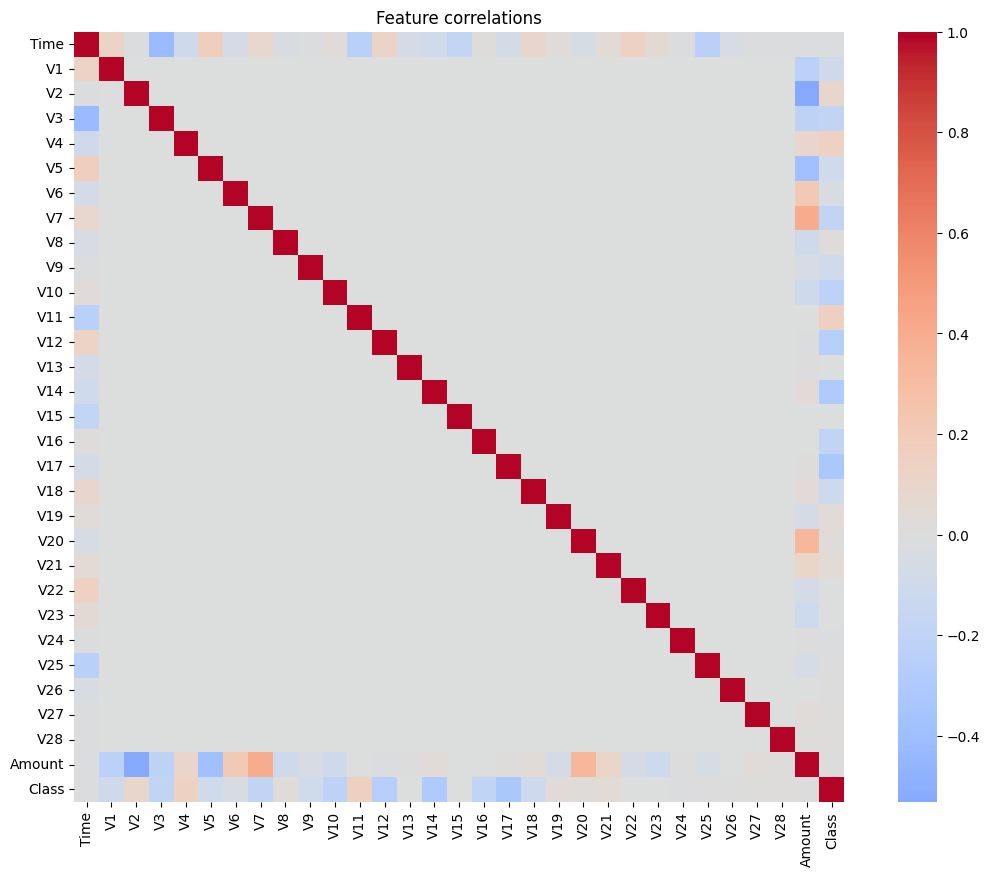

In [4]:
plt.figure(figsize=(14, 10))
sns.heatmap(data.corr(), cmap='coolwarm', center=0, square=True)
plt.title('Feature correlations')
plt.show()

## 3. Train/test split and baseline

One stratified split, used for every model below, so the comparison is fair. The baseline is a plain Random Forest with `class_weight="balanced"` and no resampling.

In [5]:
X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", Counter(y_train))
print("Test: ", Counter(y_test))

Train: Counter({0: 227451, 1: 394})
Test:  Counter({0: 56864, 1: 98})


In [6]:
rf_base = RandomForestClassifier(n_estimators=30, max_depth=12, min_samples_leaf=2,
                                 class_weight='balanced', n_jobs=-1, random_state=42)
rf_base.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_featu

## 4. Resampling

I resample only the training set. The test set stays untouched.

- **SMOTE** creates synthetic fraud examples.
- **Random undersampling** throws away most of the normal ones.

In [7]:
X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_train, y_train)
X_rus, y_rus = RandomUnderSampler(random_state=42).fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_smote))
print("After undersampling:", Counter(y_rus))

After SMOTE: Counter({0: 227451, 1: 227451})
After undersampling: Counter({0: 394, 1: 394})


## 5. Models

In [8]:
rf_params = dict(n_estimators=30, max_depth=12, min_samples_leaf=2, n_jobs=-1, random_state=42)

rf_smote = RandomForestClassifier(**rf_params).fit(X_smote, y_smote)
rf_rus = RandomForestClassifier(**rf_params).fit(X_rus, y_rus)
xgb_smote = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                          random_state=42).fit(X_smote, y_smote)

models = {
    'RF baseline (class_weight)': rf_base,
    'RF + SMOTE': rf_smote,
    'RF + undersampling': rf_rus,
    'XGBoost + SMOTE': xgb_smote,
}

## 6. Comparison

All numbers are for the fraud class on the test set. The test set has only 98 fraud cases, so one extra catch moves recall by about 0.01. Small differences between models don't mean much.

In [9]:
probas = {name: m.predict_proba(X_test)[:, 1] for name, m in models.items()}

def score(name, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {'Model': name,
            'Recall': recall_score(y_test, pred),
            'Precision': precision_score(y_test, pred, zero_division=0),
            'F1': f1_score(y_test, pred),
            'PR-AUC': average_precision_score(y_test, proba),
            'ROC-AUC': roc_auc_score(y_test, proba)}

results = pd.DataFrame([score(n, p) for n, p in probas.items()]).set_index('Model')
results.round(3)

,Recall,Precision,F1,PR-AUC,ROC-AUC
Model,,,,,
RF baseline (class_weight),0.847,0.709,0.772,0.823,0.978
RF + SMOTE,0.878,0.597,0.711,0.788,0.984
RF + undersampling,0.918,0.039,0.076,0.683,0.973
XGBoost + SMOTE,0.888,0.527,0.662,0.861,0.978


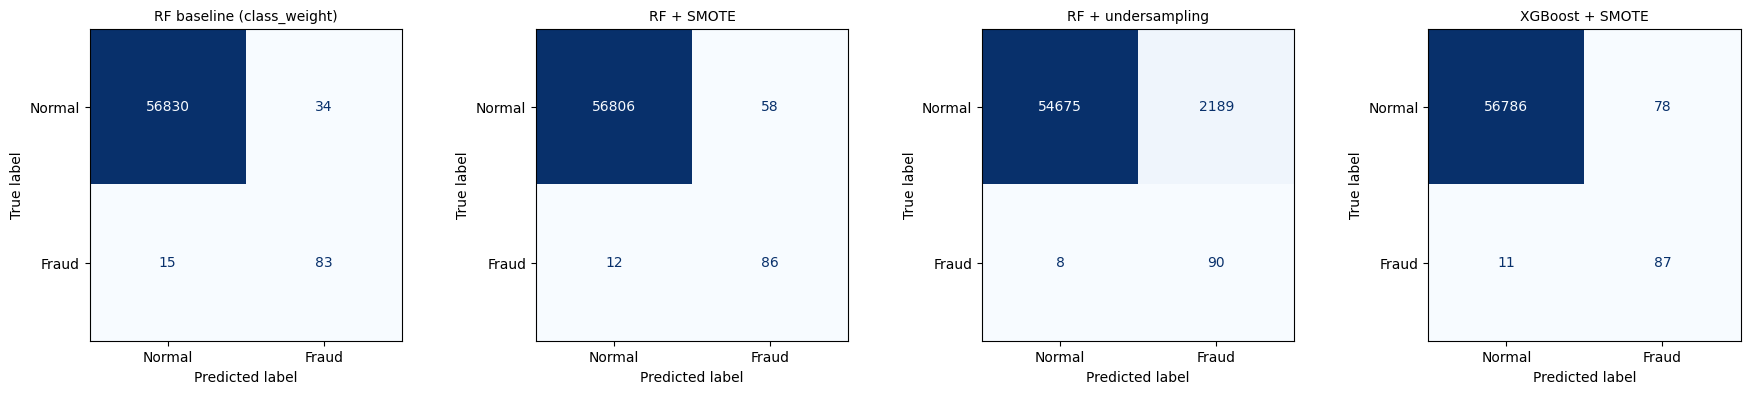

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, p) in zip(axes, probas.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, (p >= 0.5).astype(int), ax=ax,
                                            display_labels=['Normal', 'Fraud'],
                                            cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

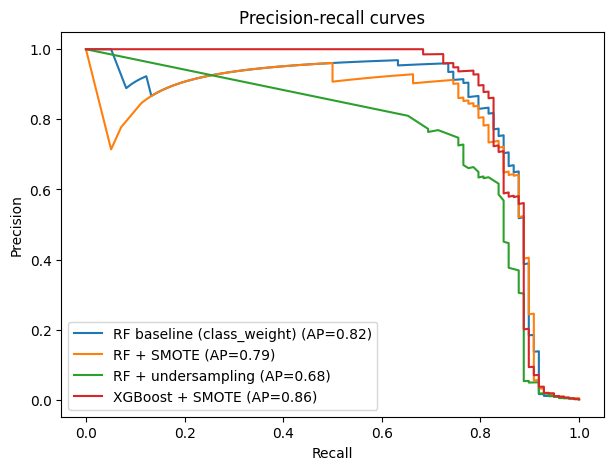

In [11]:
plt.figure(figsize=(7, 5))
for name, p in probas.items():
    prec, rec, _ = precision_recall_curve(y_test, p)
    plt.plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, p):.2f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-recall curves')
plt.legend()
plt.show()

In [12]:
print("Best F1:    ", results['F1'].idxmax())
print("Best PR-AUC:", results['PR-AUC'].idxmax())

Best F1:     RF baseline (class_weight)
Best PR-AUC: XGBoost + SMOTE


## 7. Threshold tuning

The default cutoff is 0.5, which is arbitrary. I pick a better one for RF + SMOTE using cross-validated predictions on the **training** data only, then check it once on the test set. Choosing the threshold by looking at test results would make the score look better than it really is.

Threshold with best cross-validated F1: 0.76


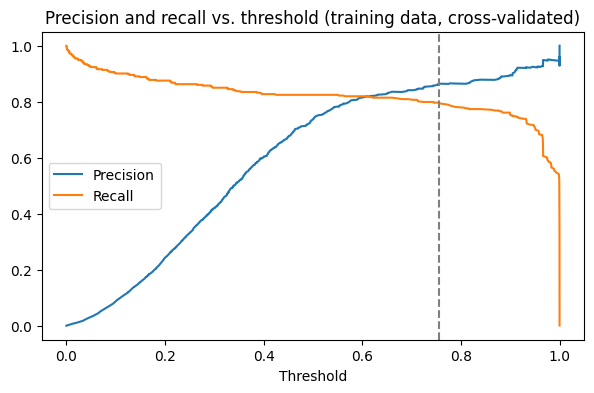

In [13]:
pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(**rf_params)),
])
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
oof = cross_val_predict(pipe, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

prec, rec, thr = precision_recall_curve(y_train, oof)
f1_curve = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_thr = thr[np.argmax(f1_curve)]
print(f"Threshold with best cross-validated F1: {best_thr:.2f}")

plt.figure(figsize=(7, 4))
plt.plot(thr, prec[:-1], label='Precision')
plt.plot(thr, rec[:-1], label='Recall')
plt.axvline(best_thr, color='gray', linestyle='--')
plt.xlabel('Threshold')
plt.title('Precision and recall vs. threshold (training data, cross-validated)')
plt.legend()
plt.show()

In [14]:
p = probas['RF + SMOTE']
print(f"--- RF + SMOTE at threshold {best_thr:.2f} (test set) ---")
print(classification_report(y_test, (p >= best_thr).astype(int)))

tuned = score(f'RF + SMOTE (threshold {best_thr:.2f})', p, best_thr)
results.loc[tuned.pop('Model')] = tuned
results.round(3)

--- RF + SMOTE at threshold 0.76 (test set) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.80      0.81      0.80        98

    accuracy                           1.00     56962
   macro avg       0.90      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



,Recall,Precision,F1,PR-AUC,ROC-AUC
Model,,,,,
RF baseline (class_weight),0.847,0.709,0.772,0.823,0.978
RF + SMOTE,0.878,0.597,0.711,0.788,0.984
RF + undersampling,0.918,0.039,0.076,0.683,0.973
XGBoost + SMOTE,0.888,0.527,0.662,0.861,0.978
RF + SMOTE (threshold 0.76),0.806,0.798,0.802,0.788,0.984


## 8. What I took from this

- Accuracy is useless here. Recall, precision, F1 and PR-AUC are what matter.
- Always run a strong baseline first. Compare every model on the same split.
- Undersampling gives high recall but a flood of false alarms. Check the table for how it compares with SMOTE.
- The threshold is a business decision (missed fraud vs. false alarms), and it should be picked without touching the test set.
- With 98 fraud cases in the test set, small gaps between models are noise. Cross-validating every model would be the next step.

**Next:** tune XGBoost (`scale_pos_weight`, `max_depth`), try ADASYN or SMOTE + Tomek links, and wrap the best model in a small API.